# Autofocus

In [ ]:
# Needed to import from the enderscope library

import os

os.chdir("..")
.

In [20]:
from picamera2 import Picamera2
try:
    cam
except NameError:
    pass
else:
    cam.close()
cam = Picamera2()
cam.start(show_preview=True)

[7:44:10.259513601] [3904]  INFO Camera camera_manager.cpp:325 libcamera v0.3.2+27-7330f29b
[7:44:10.266921315] [8963]  INFO RPI pisp.cpp:695 libpisp version v1.0.7 28196ed6edcf 29-08-2024 (16:33:32)
[7:44:10.278351534] [8963]  INFO RPI pisp.cpp:1154 Registered camera /base/axi/pcie@120000/rp1/i2c@88000/imx219@10 to CFE device /dev/media0 and ISP device /dev/media1 using PiSP variant BCM2712_C0
[7:44:10.281425690] [3904]  INFO Camera camera.cpp:1197 configuring streams: (0) 640x480-XBGR8888 (1) 640x480-BGGR_PISP_COMP1
[7:44:10.281520727] [8963]  INFO RPI pisp.cpp:1450 Sensor: /base/axi/pcie@120000/rp1/i2c@88000/imx219@10 - Selected sensor format: 640x480-SBGGR10_1X10 - Selected CFE format: 640x480-PC1B


In [24]:
cam.set_controls({'AwbEnable':True,'AeEnable':False})
cam.set_controls({'ExposureTime':50000, 'AnalogueGain':3.0})

In [ ]:
from enderscope.serial import SerialUtils, Stage
# list available serial ports
ports = SerialUtils.serial_ports()
print (ports)

['/dev/ttyAMA10', '/dev/ttyACM0', '/dev/ttyUSB0']


In [3]:
lightport = ports[1]
stageport = ports[2]
s = Stage(stageport, 115200)
s.home()

In [4]:
import numpy as np
import cv2

# Laplacian variance calculus function
def Var(img):
    laplacian = cv2.Laplacian(img, cv2.CV_32F)
    variance = laplacian.var()
    return variance

In [12]:
s.move_position([55,75,30])

In [13]:
zrange = np.array(range(-10,10,1))*1.5
zrange

array([-15. , -13.5, -12. , -10.5,  -9. ,  -7.5,  -6. ,  -4.5,  -3. ,
        -1.5,   0. ,   1.5,   3. ,   4.5,   6. ,   7.5,   9. ,  10.5,
        12. ,  13.5])

In [14]:
pos = s.get_position()
mxScore = -1
bestZ = 0
variances = []

for z in zrange:
    s.move_position([pos[0],pos[1],z+pos[2]])
    s.finish_moves()
    img = cam.capture_array("main")
    grayImage = (np.float32(img[:,:,0])+np.float32(img[:,:,1])+np.float32(img[:,:,2]))/3
    score = Var(grayImage)
    variances.append(score)
    if score>mxScore:
        mxScore = score
        bestZ = z

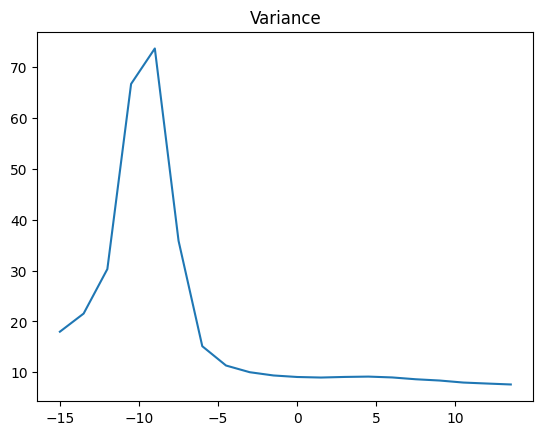

In [15]:
import matplotlib.pyplot as plt
plt.title('Variance')
plt.plot(zrange,variances)


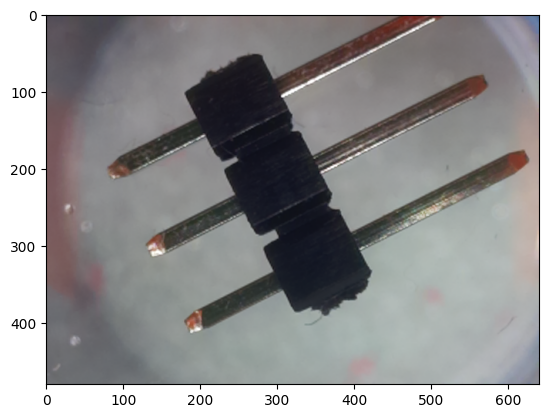

In [17]:
s.move_position([pos[0],pos[1],pos[2]+bestZ])
s.finish_moves()
img = cam.capture_array("main")
imgplot = plt.imshow(img)